# DERCO Chile — From 550k Car Sales to a Business-Model Decision
### Business Intelligence · Final Integrative Project · IIB415A · UDD · 2026

**BI unit:** Vicente Rodríguez · Agustín Reyes · Luis-Felipe Cáceres · Baptiste Vial
**Dataset:** `ventas_derco_encrypt_exam_TOPD_2009_2022.xlsx` — 550,033 raw rows (550,032 after cleaning), May 2009 → Mar 2022
**Client:** DERCO Chile — Commercial & Strategy leadership

---

#### How to read this notebook
This notebook is written so that **someone who has never done data analysis can follow every step**. Each of the five
BI stages below opens with a plain-language explanation of *what we are about to do and why it matters for the business*,
then the code, then a reading of the result.

| Stage | What we do | Why the client cares |
|---|---|---|
| **1 · Frame & KPIs** | Turn a vague ask into a sharp business question, a named decision-maker and measurable KPIs | You cannot manage what you cannot measure |
| **2 · Prepare data** | Load, clean, audit quality, handle missing values & outliers, engineer features | Bad data → confident but wrong decisions |
| **3 · Model & evaluate** | (A) segment customers, (B) predict loss-making deals — both honestly validated | Turns description into *foresight* |
| **4 · Communicate** | Insights, one clear recommendation, dashboard | A model nobody acts on is worth zero |
| **5 · Ethics & limits** | Bias, privacy, and what this analysis *cannot* say | Trustworthy BI states its own boundaries |

> **Reproducibility:** every number and figure below is produced by running the notebook top-to-bottom
> (*Kernel → Restart & Run All*). A fixed random seed (`SEED = 42`) makes the models deterministic.
> **AI-use disclosure** is at the end (§6), per the course policy.

---
# Stage 1 · Frame & KPIs

Before touching a single row, a BI team decides **what decision the analysis will serve**. A perfect model that
answers no business question is worthless; a modest model tied to a clear decision is valuable.

### 1.1 The business question
> **"After 14 years of sales, where is DERCO's retail model leaking value, and what should change to grow margin?"**

### 1.2 Who decides, and what they will do differently
- **Decision-maker:** DERCO's Commercial Director (owns brand mix, channel strategy and the marketing budget).
- **Decision on the table:** how to reallocate commercial effort across **(a)** which brands to push, **(b)** the
  dealer (`ces`) vs own-store (`propio`) channel, and **(c)** whether to fund a customer-retention program.
- **What changes because of us:** a concrete, ranked list of where to move budget next fiscal year.

### 1.3 KPIs (how we measure success)
| KPI | Definition | Why it matters |
|---|---|---|
| **Transactions** | count of sales | demand / market presence |
| **Revenue (synthetic)** | Σ `precio_de_lista_synt` | top-line scale |
| **Retail margin** | Σ `margen_retail` | the money the business actually keeps |
| **Margin %** | margin ÷ list price | pricing health per deal |
| **Repeat-customer rate** | customers with ≥2 purchases | loyalty / lifetime value |
| **Loss-making-deal rate** | share of sales with margin < 0 | value leakage |

### 1.4 Success metric for *this project*
Deliver **(1)** a customer segmentation that tells the Commercial Director *who to retain*, and **(2)** a model that
flags *which deals leak margin* — each tied to a **CLP-valued** estimate the business can act on.

> ⚠️ **Data caveat, stated up-front:** `precio_de_lista_synt` and `margen_retail` are **synthetically generated /
> obfuscated** for this exam dataset. We therefore treat money as **relative signal** — rankings, shares and trends
> are valid; absolute CLP figures are **not** production financials.

---
# Stage 2 · Prepare the data

Real data is never clean. This stage loads the file, gives every column a name and a type, then runs a full
**quality audit** — missing values, duplicates, outliers, logical contradictions — and finally engineers the extra
columns the models will need. We **document every decision** so a reviewer can challenge it.

### 2.1 Libraries and the reproducibility seed

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

# --- reproducibility: one seed governs every random step in this notebook ---
SEED = 42
np.random.seed(SEED)

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

# --- where the files live -------------------------------------------------
# Resolved, not hard-coded, so the notebook runs unchanged from notebooks/, from the
# repo root, from the flat delivery folder, or from Colab (upload the .xlsx first).
XLSX = 'ventas_derco_encrypt_exam_TOPD_2009_2022.xlsx'

def _resolve_root() -> Path:
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / 'data').is_dir() or (base / XLSX).exists():
            return base
    return Path.cwd()

ROOT = _resolve_root()
DATA = ROOT / 'data' if (ROOT / 'data').is_dir() else ROOT          # inputs + clean outputs
PRES = ROOT / 'presentation' if (ROOT / 'presentation').is_dir() else ROOT  # dashboard.png, metrics.json
print(f'Data folder:         {DATA}')
print(f'Presentation folder: {PRES}')

# --- DERCO visual identity: red on white, one palette across every chart ---
# Marks are checked for >=3:1 contrast on the white chart surface and for colour-vision-deficiency
# separation (OKLab dE >= 8 between any two series that ever sit side by side).
RED   = '#c00512'   # DERCO brand red — series slot 1 / emphasis (6.4:1 on white)
BLUE  = '#2a78d6'   # series slot 2 — the contrasting series (incumbent brands)
GREEN = '#0ca30c'   # positive / opportunity
INK   = '#1a1a1a'   # primary text
MUTED = '#767676'   # axis + secondary text
GRID  = '#e5e4e0'   # hairline grid
# Ordered one-hue ramp for the 4 value tiers of the segmentation (dark = most valuable).
# The segments are ranked, so their colour must be ordered too — not four unrelated hues.
RED_RAMP = ['#8c0410', '#c00512', '#e94b45', '#f6a09b']
# Big filled areas take a light tint of the same hue — saturated colour is for small marks
# and accents only, never for a block that covers half the chart.
RED_FILL, BLUE_FILL = '#f6a09b', '#9ec5f4'

plt.rcParams.update({
    'figure.figsize': (11, 5), 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.edgecolor': GRID,
    'axes.labelcolor': INK, 'text.color': INK, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.titlepad': 12, 'legend.frameon': False, 'font.size': 10, 'savefig.facecolor': 'white',
})

print('pandas', pd.__version__)

pandas 3.0.3


### 2.2 Loading & parsing

The source `.xlsx` has a single sheet (`in`) whose **one column packs all ten fields, pipe-delimited (`|`)**. We split
it into a proper table and assign correct types. Loading raw text first (then converting) lets us catch bad values
instead of letting pandas silently guess.

In [2]:
SRC = DATA / XLSX

raw = pd.read_excel(SRC, sheet_name='in')
print('Raw shape:', raw.shape)
print('The single packed column header:\n ', raw.columns.tolist()[0])

COLS = ['fecha_transaccion', 'encrypt_rut', 'direccion', 'comuna', 'marca',
        'detalle', 'margen_retail', 'retail', 'year', 'precio_de_lista_synt']

df = raw.iloc[:, 0].astype(str).str.split('|', expand=True)
df.columns = COLS
print('Parsed shape:', df.shape)

Raw shape: (550033, 1)
The single packed column header:
  fecha_transaccion|encrypt-rut|direccion|comuna|marca|detalle|margen_retail|retail|year|precio_de_lista_synt


Parsed shape: (550033, 10)


In [3]:
# --- assign correct dtypes; errors='coerce' turns any unparseable value into NaN so we can find it ---
df['fecha_transaccion']  = pd.to_datetime(df['fecha_transaccion'], errors='coerce')
df['year']               = pd.to_numeric(df['year'], errors='coerce').astype('Int64')
df['margen_retail']      = pd.to_numeric(df['margen_retail'], errors='coerce')
df['precio_de_lista_synt'] = pd.to_numeric(df['precio_de_lista_synt'], errors='coerce')

# strip whitespace and normalise empty strings / literal 'nan' to real missing values
for c in ['direccion', 'comuna', 'marca', 'detalle', 'retail']:
    df[c] = df[c].replace({'': np.nan, 'nan': np.nan}).str.strip()

df.head()

,fecha_transaccion,encrypt_rut,direccion,comuna,marca,detalle,margen_retail,retail,year,precio_de_lista_synt
0,2021-12-24,35b173e721e61f2c5bb49acc9916c1c339ee9ae0da65be...,SANTA AMALIA 903,LA FLORIDA,Suzuki,SPRESSO 1.0 GLX AC,567394.93750,ces,2021,6.752686e+06
1,2020-08-27,fce2c2db1201aefad070990185876045562052cce43e03...,FUNDO EL CARMEN PARCELA K SN,CONCEPCION,Suzuki,SPRESSO 1.0 GLX AC,283069.62500,ces,2020,5.214904e+06
2,2021-02-27,59f2977fe450d10a6b54f6f543fc1317ffb4de4b58101f...,CARLOS DIAZ OSSA 2991,CALAMA,Suzuki,SPRESSO 1.0 GLX AC,427899.59375,ces,2021,6.508553e+06
3,2020-03-31,b7e22c19543e809ebc51465b46b6b3032ee4f46c9acb62...,AV ALEJANDRO LARENAS 313,RENAICO,Suzuki,SPRESSO 1.0 GLX AC,329022.28125,ces,2020,5.650630e+06
4,2020-05-08,38720f3ebbbba96729b2677ec0dab8c75477f2782da9b3...,AVDA LA ESTRELLA 1480,CERRO NAVIA,Suzuki,SPRESSO 1.0 GLX AC,305159.28125,ces,2020,5.050949e+06


### 2.3 Data dictionary

| Field | Type | Meaning |
|---|---|---|
| `fecha_transaccion` | date | when the sale was booked |
| `encrypt_rut` | hash | anonymised customer ID (stable key — one person = one hash) |
| `direccion` | text | customer street address (free text) |
| `comuna` | text | Chilean municipality (geographic unit) |
| `marca` | text | vehicle brand |
| `detalle` | text | model + trim |
| `margen_retail` | float | retail margin per sale (CLP, synthetic) |
| `retail` | cat | channel: `ces` = dealer network, `propio` = DERCO-owned store |
| `year` | int | transaction year (redundant with the date) |
| `precio_de_lista_synt` | float | synthetic list price (CLP) |

### 2.4 Quality audit — the "can we trust this?" check

We check five things every BI team checks: **shape, missing values, duplicates, logical consistency, and outliers.**

In [4]:
print(f'Rows:              {len(df):,}')
print(f'Columns:           {df.shape[1]}')
print(f'Date range:        {df.fecha_transaccion.min().date()} -> {df.fecha_transaccion.max().date()}')
print(f'Unique customers:  {df.encrypt_rut.nunique():,}')
print(f'Unique brands:     {df.marca.nunique()}')
print(f'Unique models:     {df.detalle.nunique():,}')
print(f'Unique comunas:    {df.comuna.nunique()}')

Rows:              550,033
Columns:           10
Date range:        2009-05-05 -> 2022-03-28
Unique customers:  464,226
Unique brands:     9
Unique models:     1,543
Unique comunas:    511


In [5]:
# per-column quality table
quality = pd.DataFrame({
    'dtype':    df.dtypes.astype(str),
    'nulls':    df.isna().sum(),
    'null_%':   (df.isna().mean() * 100).round(3),
    'n_unique': df.nunique(),
})
quality

,dtype,nulls,null_%,n_unique
fecha_transaccion,datetime64[us],0,0.000,4529
encrypt_rut,str,0,0.000,464226
direccion,str,3942,0.717,411028
comuna,str,3942,0.717,511
marca,str,0,0.000,9
detalle,str,0,0.000,1543
margen_retail,float64,0,0.000,367036
retail,str,0,0.000,2
year,Int64,0,0.000,14
precio_de_lista_synt,float64,1,0.000,550032


In [6]:
# logical-consistency checks
mismatch = int((df.fecha_transaccion.dt.year != df.year).sum())
dups     = int(df.duplicated().sum())
neg_marg = int((df.margen_retail < 0).sum())
zero_marg= int((df.margen_retail == 0).sum())
null_price = int(df.precio_de_lista_synt.isna().sum())

print(f'Rows where date.year != year column : {mismatch}   (0 = perfectly consistent)')
print(f'Exact duplicate rows                : {dups}')
print(f'Rows with a NULL list price         : {null_price}')
print(f'Sales with NEGATIVE margin          : {neg_marg:,}  ({neg_marg/len(df)*100:.2f}% -> value leakage!)')
print(f'Sales with ZERO margin              : {zero_marg}')

Rows where date.year != year column : 0   (0 = perfectly consistent)
Exact duplicate rows                : 0
Rows with a NULL list price         : 1
Sales with NEGATIVE margin          : 11,966  (2.18% -> value leakage!)
Sales with ZERO margin              : 26


**Reading the audit**
- **Missing values** are tiny and confined to `direccion`/`comuna` (~0.72%). These rows still carry a valid brand,
  price and margin, so we **flag them (`UNKNOWN`) rather than drop them** — dropping would silently shrink revenue totals.
- **`year` is 100% redundant** with `fecha_transaccion` (0 mismatches) → we drop it to avoid two sources of truth.
- **No exact duplicates.**
- **11,966 sales (2.18%) have a *negative* margin** — DERCO sold these cars *below cost*. This is not a parsing error;
  it is a **real business finding worth ≈ 6.8 bn CLP of leaked margin**, and it becomes the target of our second model.

### 2.5 Missing values & outliers — decide and document

| Issue | Decision | Rationale |
|---|---|---|
| `comuna`/`direccion` null (0.72%) | fill `comuna` → `'UNKNOWN'`, keep the row | preserves revenue; geography just becomes "unknown" |
| 1 row with null list price | drop | cannot compute price/margin KPIs without it |
| `year` column | drop | redundant with the date |
| negative margins (2.18%) | **keep + flag** `loss_making` | real signal, not noise — it is a modeling target |
| extreme monetary values (RFM) | **log-transform** later, don't delete | a few fleet buyers are real customers, not errors |

In [7]:
before = len(df)
df = df.dropna(subset=['precio_de_lista_synt']).copy()   # 1 unusable row
df['comuna'] = df['comuna'].fillna('UNKNOWN')
df = df.drop(columns=['year'])                            # redundant
print(f'Dropped {before - len(df)} unusable row(s). Working rows: {len(df):,}')

Dropped 1 unusable row(s). Working rows: 550,032


### 2.6 Feature engineering — build the columns the models need

Good features encode business logic the raw file only implies.

In [8]:
# time features
df['year']    = df.fecha_transaccion.dt.year
df['month']   = df.fecha_transaccion.dt.month
df['quarter'] = df.fecha_transaccion.dt.quarter

# business flags & ratios
df['margin_pct']  = df.margen_retail / df.precio_de_lista_synt          # pricing health per deal
df['loss_making'] = (df.margen_retail < 0).astype(int)                  # target for Model B

# brand origin — the strategic question is Chinese vs incumbent brands
CHINESE = {'JAC Cars', 'Great Wall', 'Changan', 'Geely', 'Haval'}
df['brand_origin'] = np.where(df.marca.isin(CHINESE), 'Chinese', 'Incumbent')

# price band — segments the catalogue into economy / mid / premium by tercile
df['price_band'] = pd.qcut(df.precio_de_lista_synt, q=3, labels=['Economy', 'Mid', 'Premium'])

df[['fecha_transaccion','marca','brand_origin','retail','precio_de_lista_synt',
    'margen_retail','margin_pct','loss_making','price_band']].head()

,fecha_transaccion,marca,brand_origin,retail,precio_de_lista_synt,margen_retail,margin_pct,loss_making,price_band
0,2021-12-24,Suzuki,Incumbent,ces,6.752686e+06,567394.93750,0.084025,0,Mid
1,2020-08-27,Suzuki,Incumbent,ces,5.214904e+06,283069.62500,0.054281,0,Economy
2,2021-02-27,Suzuki,Incumbent,ces,6.508553e+06,427899.59375,0.065744,0,Mid
3,2020-03-31,Suzuki,Incumbent,ces,5.650630e+06,329022.28125,0.058228,0,Economy
4,2020-05-08,Suzuki,Incumbent,ces,5.050949e+06,305159.28125,0.060416,0,Economy


### 2.7 Exploratory Data Analysis (EDA)

Now we *look* at the data. Each chart below answers one business question. This is where a BI team builds intuition
before modeling.

#### (a) Who sells the most? — brand mix

,transactions,share_%
marca,,
Suzuki,213402,38.8
Mazda,97745,17.8
Renault,59733,10.9
JAC Cars,50262,9.1
Great Wall,46646,8.5
Changan,45011,8.2
Samsung,19140,3.5
Geely,9112,1.7
Haval,8981,1.6


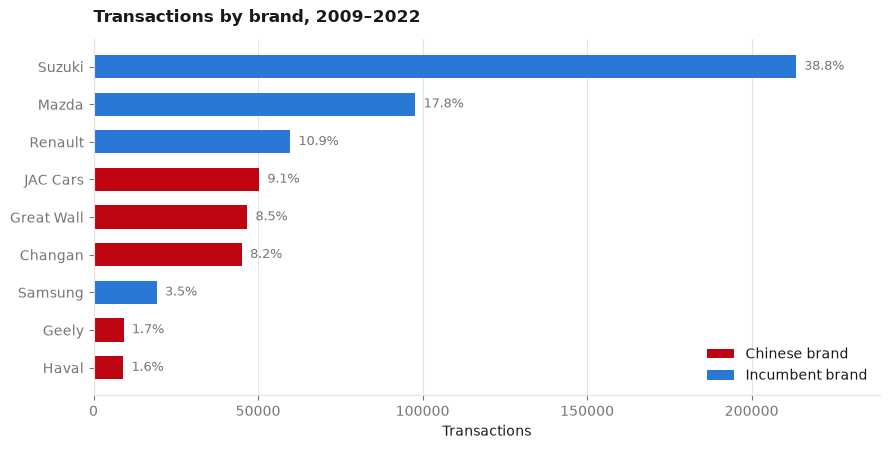

In [9]:
brand = df.marca.value_counts()
share = (brand / brand.sum() * 100).round(1)
brand_summary = pd.DataFrame({'transactions': brand, 'share_%': share})
display(brand_summary)

# Colour carries the strategic split (Chinese vs incumbent), not the bar's own rank —
# bar length already encodes volume, so the hue is free to encode brand origin.
origin_of = df.drop_duplicates('marca').set_index('marca').brand_origin
plot_order = brand.sort_values()
colors = [RED if origin_of[m] == 'Chinese' else BLUE for m in plot_order.index]

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.barh(plot_order.index, plot_order.values, color=colors, height=.62)
for name, v in plot_order.items():                      # direct labels: the value is readable without the axis
    ax.text(v + brand.max() * .012, name, f'{share[name]:.1f}%', va='center', color=MUTED, fontsize=9)
ax.set_title('Transactions by brand, 2009–2022')
ax.set_xlabel('Transactions'); ax.set_xlim(0, brand.max() * 1.12)
ax.grid(axis='y', visible=False)
ax.legend(handles=[Patch(facecolor=RED, label='Chinese brand'),
                   Patch(facecolor=BLUE, label='Incumbent brand')], loc='lower right')
plt.tight_layout(); plt.show()

> **Suzuki alone is ~39% of all sales** — heavy single-brand dependence, a concentration risk we flag for the client.

#### (b) The channel mix — dealer vs own store

,transactions,volume_share_%,margin_%,loss_rate_%
retail,,,,
ces,357983,65.1,6.24,0.46
propio,192049,34.9,5.20,5.38


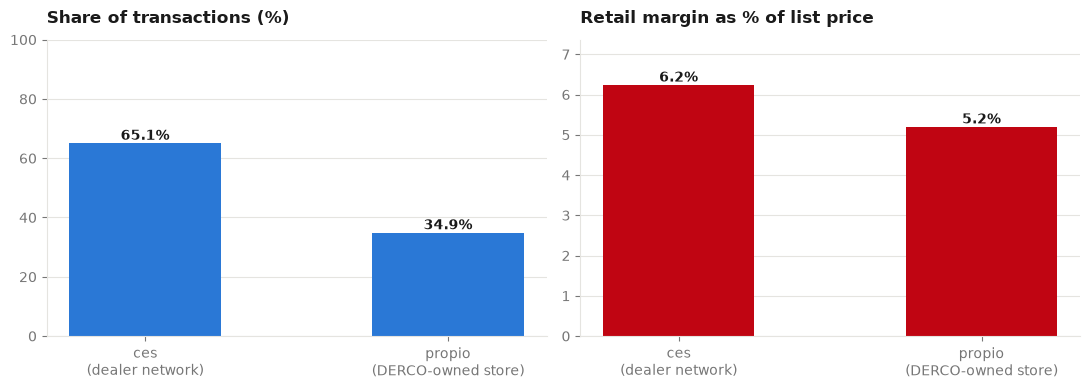

Dealer channel (ces) runs +1.04 pp of margin vs DERCO's own stores (propio).


In [10]:
# A two-slice pie hides the comparison it is supposed to make, so we show the two facts
# side by side instead: how much each channel SELLS, and how well each channel PRICES.
channel = df.retail.value_counts()
ch = (df.groupby('retail')
        .agg(transactions=('retail', 'size'),
             revenue=('precio_de_lista_synt', 'sum'),
             margin=('margen_retail', 'sum'),
             loss_rate=('loss_making', 'mean')))
ch['volume_share_%'] = (ch.transactions / len(df) * 100).round(1)
ch['margin_%']       = (ch.margin / ch.revenue * 100).round(2)     # aggregate margin / aggregate revenue
ch['loss_rate_%']    = (ch.loss_rate * 100).round(2)
display(ch[['transactions', 'volume_share_%', 'margin_%', 'loss_rate_%']])

labels = {'ces': 'ces\n(dealer network)', 'propio': 'propio\n(DERCO-owned store)'}
idx = ['ces', 'propio']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.bar([labels[i] for i in idx], ch.loc[idx, 'volume_share_%'], color=BLUE, width=.5)
a1.set_title('Share of transactions (%)'); a1.set_ylim(0, 100); a1.grid(axis='x', visible=False)
a2.bar([labels[i] for i in idx], ch.loc[idx, 'margin_%'], color=RED, width=.5)
a2.set_title('Retail margin as % of list price'); a2.grid(axis='x', visible=False)
for a, col in ((a1, 'volume_share_%'), (a2, 'margin_%')):
    for x, v in enumerate(ch.loc[idx, col]):
        a.text(x, v, f'{v:.1f}%', ha='center', va='bottom', color=INK, fontweight='bold')
    a.margins(y=.18)
plt.tight_layout(); plt.show()

gap = ch.loc['ces', 'margin_%'] - ch.loc['propio', 'margin_%']
print(f"Dealer channel (ces) runs {gap:+.2f} pp of margin vs DERCO's own stores (propio).")

#### (c) How did the business evolve? — volume vs revenue over 14 years

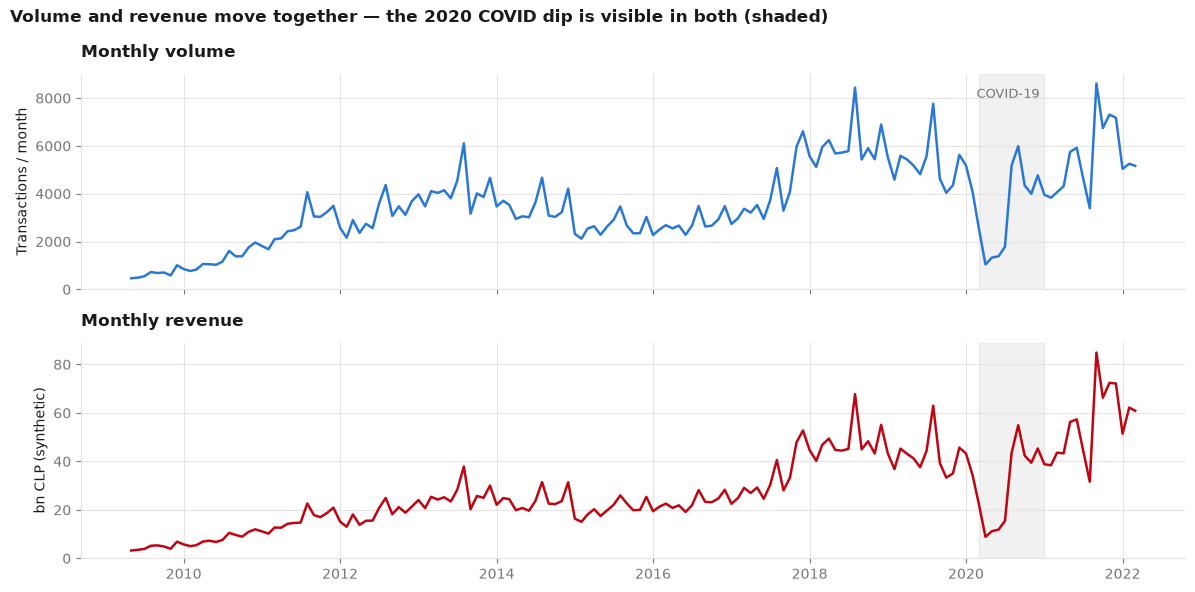

In [11]:
df['year_month'] = df.fecha_transaccion.dt.to_period('M').dt.to_timestamp()
monthly = df.groupby('year_month').agg(transactions=('encrypt_rut', 'size'),
                                       revenue=('precio_de_lista_synt', 'sum'))

# Two measures on two different scales get two panels sharing one x-axis — never two y-axes
# on one plot, which would invent a correlation by arbitrarily aligning the scales.
fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
a1.plot(monthly.index, monthly.transactions, color=BLUE, linewidth=1.8)
a1.set_ylabel('Transactions / month'); a1.set_title('Monthly volume')
a2.plot(monthly.index, monthly.revenue / 1e9, color=RED, linewidth=1.8)
a2.set_ylabel('bn CLP (synthetic)'); a2.set_title('Monthly revenue')
for a in (a1, a2):
    a.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-31'), color=MUTED, alpha=.10, zorder=0)
    a.set_ylim(bottom=0)
a1.annotate('COVID-19', xy=(pd.Timestamp('2020-07-15'), monthly.transactions.max() * .93),
            ha='center', color=MUTED, fontsize=9)
fig.suptitle('Volume and revenue move together — the 2020 COVID dip is visible in both (shaded)',
             x=.008, ha='left', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

#### (d) Seasonality — which months sell?

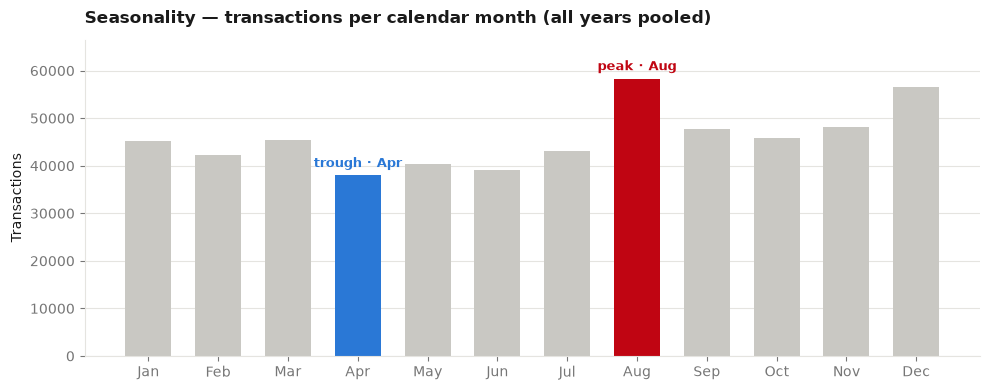

Peak month: 8 | Lowest month: 4


In [12]:
seasonal = df.groupby('month').size()
MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
peak, trough = int(seasonal.idxmax()), int(seasonal.idxmin())

# One series, so one colour — with the peak and the trough highlighted, because those two
# months are the only actionable part of the chart.
colors = [RED if m == peak else (BLUE if m == trough else '#c9c8c3') for m in seasonal.index]
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(MONTHS, seasonal.values, color=colors, width=.66)
ax.set_title('Seasonality — transactions per calendar month (all years pooled)')
ax.set_ylabel('Transactions'); ax.grid(axis='x', visible=False)
ax.annotate(f'peak · {MONTHS[peak-1]}', xy=(peak - 1, seasonal.max()), xytext=(0, 6),
            textcoords='offset points', ha='center', color=RED, fontweight='bold', fontsize=9)
ax.annotate(f'trough · {MONTHS[trough-1]}', xy=(trough - 1, seasonal.min()), xytext=(0, 6),
            textcoords='offset points', ha='center', color=BLUE, fontweight='bold', fontsize=9)
ax.margins(y=.14)
plt.tight_layout(); plt.show()
print('Peak month:', peak, '| Lowest month:', trough)

#### (e) THE strategic shift — Chinese brands vs incumbents over time

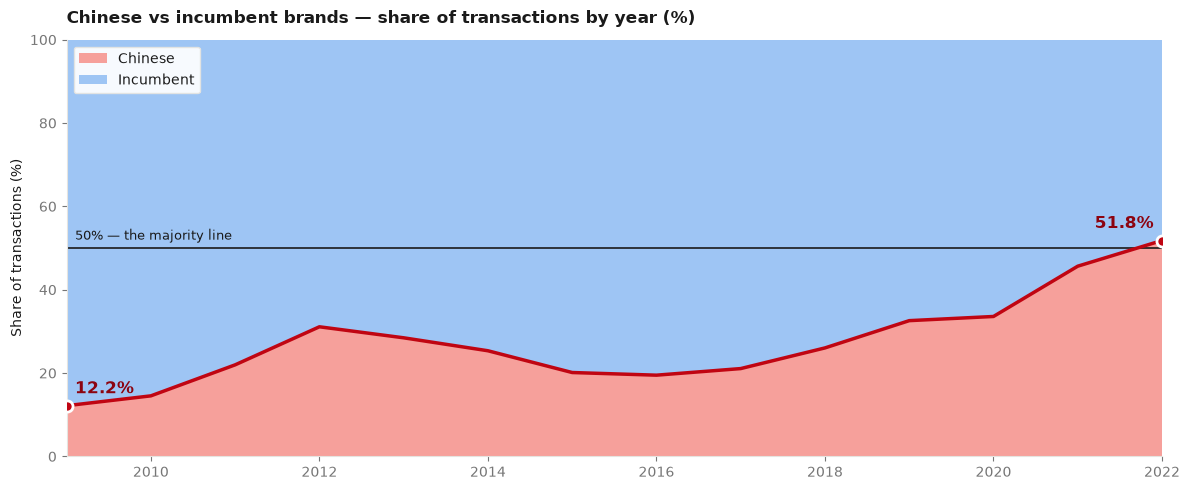

Chinese-brand share  2009: 12.2%   2021: 45.6%   2022: 51.8%
NOTE 2009 starts in May and 2022 ends in March — both are partial years; shares are still valid, totals are not.


In [13]:
origin_yr = (df.groupby(['year','brand_origin']).size()
               .unstack(fill_value=0))
origin_share = origin_yr.div(origin_yr.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(origin_share.index, origin_share['Chinese'], origin_share['Incumbent'],
             colors=[RED_FILL, BLUE_FILL], labels=['Chinese', 'Incumbent'])
# the saturated hue rides the boundary as a thin line; the block itself stays light
ax.plot(origin_share.index, origin_share['Chinese'], color=RED, linewidth=2.5, zorder=3)
ax.axhline(50, color=INK, linewidth=1.2, zorder=2)
ax.text(origin_share.index[0] + .1, 52, '50% — the majority line', color=INK, fontsize=9)
# selective direct labels: the two endpoints, not every point
for yr, dx, ha in ((origin_share.index[0], 6, 'left'), (origin_share.index[-1], -6, 'right')):
    v = origin_share.loc[yr, 'Chinese']
    ax.annotate(f'{v:.1f}%', xy=(yr, v), xytext=(dx, 9), textcoords='offset points',
                color='#8c0410', fontweight='bold', fontsize=12, ha=ha, zorder=4)
    ax.plot([yr], [v], 'o', color=RED, markersize=8, markeredgecolor='white',
            markeredgewidth=2, zorder=4)
ax.set_title('Chinese vs incumbent brands — share of transactions by year (%)')
ax.set_ylabel('Share of transactions (%)'); ax.set_ylim(0, 100)
ax.set_xlim(origin_share.index.min(), origin_share.index.max())
ax.grid(visible=False); ax.legend(loc='upper left', frameon=True, facecolor='white', framealpha=.92, edgecolor=GRID)
plt.tight_layout(); plt.show()
print('Chinese-brand share  2009: {:.1f}%   2021: {:.1f}%   2022: {:.1f}%'.format(
      origin_share.loc[2009,'Chinese'], origin_share.loc[2021,'Chinese'], origin_share.loc[2022,'Chinese']))
print('NOTE 2009 starts in May and 2022 ends in March — both are partial years; shares are still valid, totals are not.')

> **This is the headline of the whole project.** Chinese brands went from **~12% of sales in 2009 to ~52% in 2022** —
> they now sell **the majority** of DERCO's cars. Any 2026 strategy that still treats them as a side bet is mispriced.

#### (f) Geography — where do customers live, and how concentrated is it?

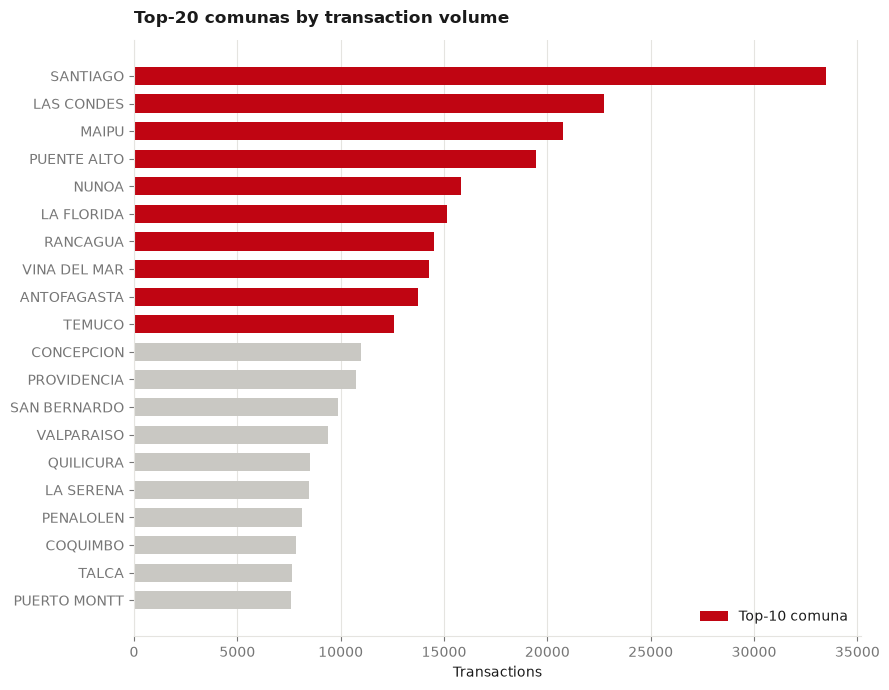

Top-10 comunas  -> 33.4% of all sales
Top-20 comunas  -> 49.8% of all sales
Top-50 comunas  -> 74.6% of all sales   (out of 511 comunas with a sale)


In [14]:
geo = (df[df.comuna != 'UNKNOWN'].groupby('comuna')
         .agg(transactions=('encrypt_rut','size'), revenue=('precio_de_lista_synt','sum'))
         .sort_values('transactions', ascending=False))
top20 = geo.head(20).transactions.sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
# One series -> one colour; the top-10 (the concentration story) is emphasised, the rest recede.
top10_names = set(geo.head(10).index)
ax.barh(top20.index, top20.values, height=.66,
        color=[RED if c in top10_names else '#c9c8c3' for c in top20.index])
ax.set_title('Top-20 comunas by transaction volume'); ax.set_xlabel('Transactions')
ax.grid(axis='y', visible=False)
ax.legend(handles=[Patch(facecolor=RED, label='Top-10 comuna')], loc='lower right')
plt.tight_layout(); plt.show()

cum = geo.transactions.cumsum() / geo.transactions.sum() * 100
print(f'Top-10 comunas  -> {cum.iloc[9]:.1f}% of all sales')
print(f'Top-20 comunas  -> {cum.iloc[19]:.1f}% of all sales')
print(f'Top-50 comunas  -> {cum.iloc[49]:.1f}% of all sales   (out of {len(geo)} comunas with a sale)')

#### (g) Margin health — the negative-margin leak, by brand

,loss_rate,n,leaked_bn
marca,,,
Mazda,4.15,97745,-3.42
Samsung,3.65,19140,-0.12
Haval,3.43,8981,-0.24
Renault,2.18,59733,-0.68
Suzuki,1.78,213402,-1.61
JAC Cars,1.32,50262,-0.27
Geely,1.22,9112,-0.03
Great Wall,1.21,46646,-0.27
Changan,1.05,45011,-0.20


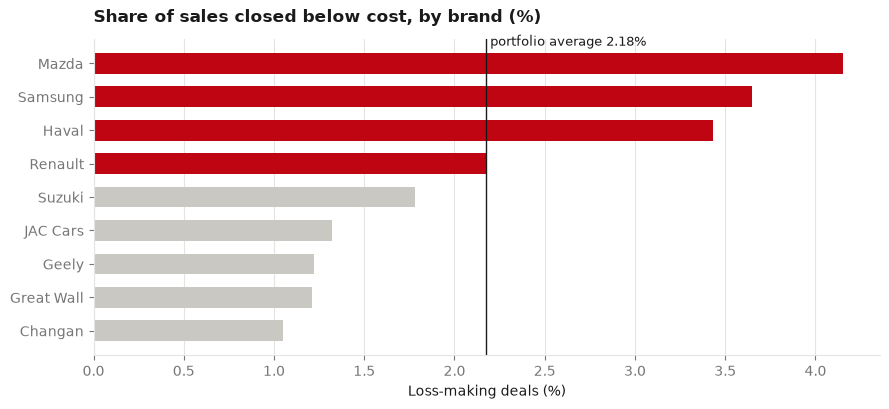

Total leaked margin from loss-making sales: -6.84 bn CLP (synthetic)


In [15]:
loss_by_brand = (df.groupby('marca')
                   .agg(loss_rate=('loss_making','mean'),
                        n=('loss_making','size'),
                        leaked_bn=('margen_retail', lambda s: s[s < 0].sum() / 1e9))
                   .assign(loss_rate=lambda d: (d.loss_rate*100).round(2),
                           leaked_bn=lambda d: d.leaked_bn.round(2))
                   .sort_values('loss_rate', ascending=False))
display(loss_by_brand)

overall = df.loss_making.mean() * 100
lb = loss_by_brand.loss_rate.sort_values()
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(lb.index, lb.values, height=.62, color=[RED if v > overall else '#c9c8c3' for v in lb.values])
ax.axvline(overall, color=INK, linewidth=1)
ax.text(overall, len(lb) - .35, f' portfolio average {overall:.2f}%', color=INK, fontsize=9, va='center')
ax.set_title('Share of sales closed below cost, by brand (%)'); ax.set_xlabel('Loss-making deals (%)')
ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

total_leak = df.loc[df.loss_making==1, 'margen_retail'].sum()
print(f'Total leaked margin from loss-making sales: {total_leak/1e9:.2f} bn CLP (synthetic)')

#### (h) EDA — key takeaways
- **Brand concentration:** Suzuki ≈ 39% of volume → single-brand dependence risk.
- **Structural shift:** Chinese brands 12% → 52% of sales across the 14 years on record — the defining trend.
- **Channel:** dealer network (`ces`) ≈ 65% of volume **and the higher margin %** (6.2% vs 5.2%) — own stores ≈ 35%.
- **Channel risk:** own stores (`propio`) close **5.4%** of deals below cost against **0.5%** at dealers — an
  ~11× gap that makes `retail` a prime feature for Model B.
- **Geography:** top-10 comunas ≈ 33% of sales — dense but over-exposed to Santiago metro.
- **Seasonality:** August peaks, April troughs (December is a close second peak) — plan inventory & campaigns around it.
- **Value leak:** 2.18% of deals lose money (~6.8 bn CLP ≈ 2.7% of total retail margin), worst in Mazda/Samsung.
- **Loyalty:** we quantify repeat behaviour next, in the model.
- **Quality:** <1% nulls, no duplicates, dates consistent → safe to model.
- **Partial end-years:** 2009 starts in May and 2022 ends in March — compare *shares*, never *totals*, at the edges.

### 2.8 Save the clean, analysis-ready dataset

We persist the cleaned table to **Parquet** (fast, typed, ~10× smaller than xlsx) plus a small CSV sample, so every
downstream step — and the graders — start from an identical, documented artifact.

In [16]:
OUT = DATA
clean_cols = ['fecha_transaccion','encrypt_rut','comuna','marca','detalle','brand_origin',
              'retail','precio_de_lista_synt','margen_retail','margin_pct','loss_making',
              'price_band','year','month','quarter']
clean = df[clean_cols].copy()
clean.to_parquet(OUT/'derco_sales_clean.parquet', index=False)
clean.sample(2000, random_state=SEED).to_csv(OUT/'derco_sales_sample.csv', index=False)
print('Saved derco_sales_clean.parquet', clean.shape, 'and a 2,000-row CSV sample.')

Saved derco_sales_clean.parquet (550032, 15) and a 2,000-row CSV sample.


---
# Stage 3 · Model & evaluate

We build **two** models, each tied to a specific decision:

- **Model A — Customer segmentation (unsupervised, KMeans on RFM).** *Who should DERCO retain?*
- **Model B — Loss-making-deal classifier (supervised).** *Which sales leak margin, before they close?*

For each we state the target, avoid leakage, use a proper validation scheme, compare against a **baseline**, and report
**metrics appropriate to the task**.

## 3A · Customer segmentation — RFM + KMeans

**Idea (RFM):** describe every customer by three numbers the whole retail industry uses —
**R**ecency (days since last purchase), **F**requency (number of purchases), **M**onetary (total spend). Then let an
algorithm group similar customers so marketing can treat each group differently.

### 3A.1 Build the RFM table

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

reference_date = df.fecha_transaccion.max() + pd.Timedelta(days=1)   # "today" for recency
rfm = (df.groupby('encrypt_rut')
         .agg(recency=('fecha_transaccion', lambda s: (reference_date - s.max()).days),
              frequency=('fecha_transaccion', 'size'),
              monetary=('precio_de_lista_synt', 'sum'),
              margin=('margen_retail', 'sum'))
         .reset_index())
print('Customers to segment:', f'{len(rfm):,}')
rfm[['recency','frequency','monetary']].describe().round(0)

Customers to segment: 464,226


,recency,frequency,monetary
count,464226.0,464226.0,4.642260e+05
mean,1788.0,1.0,9.312614e+06
std,1236.0,1.0,6.714254e+06
min,1.0,1.0,1.495007e+06
25%,804.0,1.0,5.814036e+06
50%,1515.0,1.0,7.601170e+06
75%,2863.0,1.0,1.091039e+07
max,4711.0,150.0,1.160108e+09


**Why we transform before clustering:** `frequency` and `monetary` are extremely right-skewed (a handful of fleet
buyers spend 100× the median). KMeans measures *distance*, so those few points would dominate every cluster. We
**log-transform** them to compress the tail, then **standardise** all three to mean 0 / std 1 so no single axis
outweighs the others.

In [18]:
rfm_X = rfm[['recency','frequency','monetary']].copy()
rfm_X['frequency'] = np.log1p(rfm_X['frequency'])
rfm_X['monetary']  = np.log1p(rfm_X['monetary'])
X_scaled = StandardScaler().fit_transform(rfm_X)

### 3A.2 Choosing *k* — elbow + silhouette (cluster-quality check)

We do **not** pick the number of segments by hand. We test k = 2…7 and look at two signals: the **elbow** (where adding
clusters stops reducing within-cluster spread) and the **silhouette** (how cleanly separated the clusters are, −1…1).

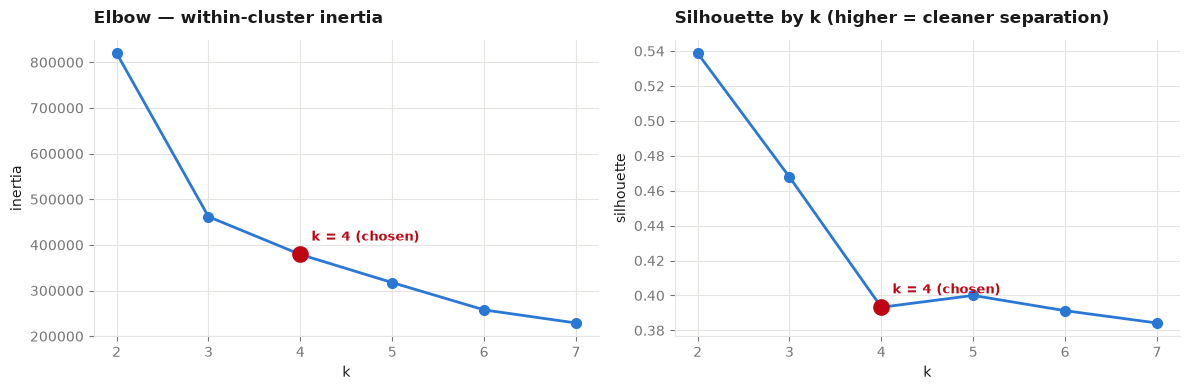

k=2  silhouette=0.539
k=3  silhouette=0.468
k=4  silhouette=0.393
k=5  silhouette=0.400
k=6  silhouette=0.391
k=7  silhouette=0.384


In [19]:
ks = range(2, 8)
inertias, sils = [], []
sample_idx = np.random.RandomState(SEED).choice(len(X_scaled), 30000, replace=False)  # sample for silhouette speed
for k in ks:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled[sample_idx], km.labels_[sample_idx]))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(list(ks), inertias, 'o-', color=BLUE, linewidth=2, markersize=7)
a1.set_title('Elbow — within-cluster inertia'); a1.set_xlabel('k'); a1.set_ylabel('inertia')
a2.plot(list(ks), sils, 'o-', color=BLUE, linewidth=2, markersize=7)
a2.set_title('Silhouette by k (higher = cleaner separation)'); a2.set_xlabel('k'); a2.set_ylabel('silhouette')
for a, ys in ((a1, inertias), (a2, sils)):          # mark the chosen k on both panels
    a.plot([4], [ys[2]], 'o', color=RED, markersize=11, zorder=5)
    a.annotate('k = 4 (chosen)', xy=(4, ys[2]), xytext=(8, 10), textcoords='offset points',
               color=RED, fontweight='bold', fontsize=9)
plt.tight_layout(); plt.show()
for k, s in zip(ks, sils): print(f'k={k}  silhouette={s:.3f}')

**Our choice: k = 4.** Silhouette alone does not settle this: k = 2 scores highest (0.54) and k = 5 (0.400)
edges k = 4 (0.393) by a statistically meaningless 0.007. So we break the tie on **actionability**, which is the
right criterion for a segmentation that has to become a marketing budget:

- **k = 2** only splits "recent vs old" — one bit of information, nothing to act on.
- **k = 5** buys no extra silhouette worth the name and splits one group into two the marketing team would treat
  identically.
- **k = 4** sits at the elbow, keeps a healthy silhouette, and maps one-to-one onto the four plays a CRM actually
  runs: **retain / grow / nurture / win-back.**

This is the *defensible k* the rubric asks for: a cluster-quality check **and** a business reason, with the
trade-off stated rather than hidden.

In [20]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=SEED, n_init=10).fit(X_scaled)
rfm['segment'] = kmeans.labels_

profile = (rfm.groupby('segment')
             .agg(customers=('encrypt_rut','size'),
                  recency_days=('recency','mean'),
                  frequency=('frequency','mean'),
                  monetary=('monetary','mean'),
                  total_margin=('margin','sum'))
             .round(0))
profile['cust_%']       = (profile.customers / len(rfm) * 100).round(1)
profile['margin_share_%'] = (profile.total_margin / rfm.margin.sum() * 100).round(1)
profile.sort_values('monetary', ascending=False)

,customers,recency_days,frequency,monetary,total_margin,cust_%,margin_share_%
segment,,,,,,,
2,64895,1270.0,2.0,18893160.0,6.539655e+10,14.0,25.7
1,105729,1035.0,1.0,11924836.0,7.777329e+10,22.8,30.6
3,150746,1088.0,1.0,6507685.0,6.176818e+10,32.5,24.3
0,142856,3320.0,1.0,5986990.0,4.952069e+10,30.8,19.5


### 3A.3 Name the segments (translate math → business)

Reading the profile table, we label each cluster and attach the action DERCO should take.

In [21]:
# order segments by monetary value and map to business names
order = profile.sort_values('monetary', ascending=False).index.tolist()
names = {order[0]: 'Champions (repeat, high-value)',
         order[1]: 'Big-ticket one-timers',
         order[2]: 'Mainstream one-timers',
         order[3]: 'Dormant / lapsed'}
rfm['segment_name'] = rfm.segment.map(names)

seg_view = (rfm.groupby('segment_name')
              .agg(customers=('encrypt_rut','size'),
                   avg_recency_days=('recency','mean'),
                   avg_purchases=('frequency','mean'),
                   total_margin_bn=('margin', lambda s: s.sum()/1e9))
              .round({'avg_recency_days':0,'avg_purchases':2,'total_margin_bn':1}))
seg_view['cust_%'] = (seg_view.customers/len(rfm)*100).round(1)
seg_view['margin_%'] = (rfm.groupby('segment_name').margin.sum()/rfm.margin.sum()*100).round(1)
seg_view.sort_values('total_margin_bn', ascending=False)

,customers,avg_recency_days,avg_purchases,total_margin_bn,cust_%,margin_%
segment_name,,,,,,
Big-ticket one-timers,105729,1035.0,1.00,77.8,22.8,30.6
"Champions (repeat, high-value)",64895,1270.0,2.31,65.4,14.0,25.7
Mainstream one-timers,150746,1088.0,1.00,61.8,32.5,24.3
Dormant / lapsed,142856,3320.0,1.00,49.5,30.8,19.5


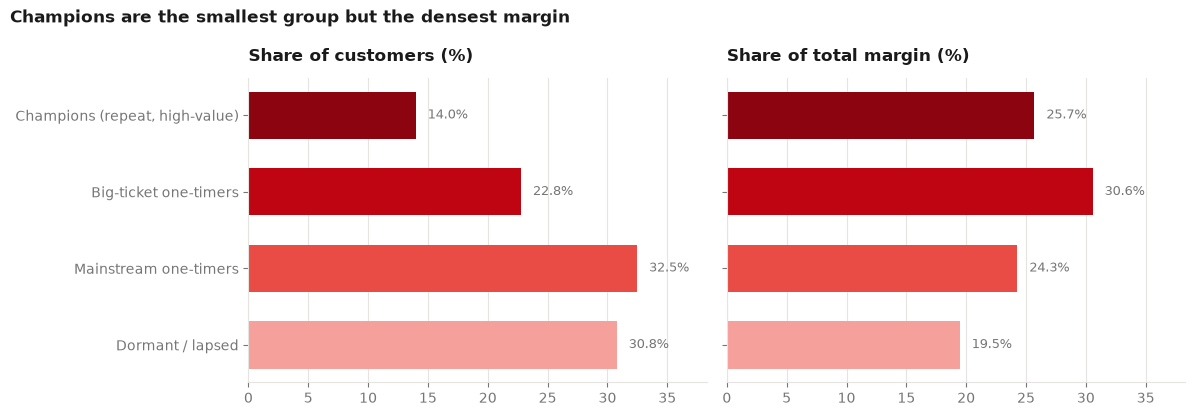

,customers_%,margin_%
segment_name,,
"Champions (repeat, high-value)",14.0,25.7
Big-ticket one-timers,22.8,30.6
Mainstream one-timers,32.5,24.3
Dormant / lapsed,30.8,19.5


In [22]:
# The four segments are RANKED by value, so their colour is one ordered red ramp, and each
# colour is bound to a NAME (not to a bar position) — sorting can never repaint a segment.
SEG_ORDER = ['Champions (repeat, high-value)', 'Big-ticket one-timers',
             'Mainstream one-timers', 'Dormant / lapsed']
SEG_COLOR = dict(zip(SEG_ORDER, RED_RAMP))

counts = rfm.segment_name.value_counts().reindex(SEG_ORDER)
margin_share = (rfm.groupby('segment_name').margin.sum() / rfm.margin.sum() * 100).reindex(SEG_ORDER)
cust_share = counts / counts.sum() * 100

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for a, vals, title in ((a1, cust_share, 'Share of customers (%)'),
                       (a2, margin_share, 'Share of total margin (%)')):
    a.barh(vals.index[::-1], vals.values[::-1], height=.62,
           color=[SEG_COLOR[s] for s in vals.index[::-1]])
    for y, v in enumerate(vals.values[::-1]):
        a.text(v + 1, y, f'{v:.1f}%', va='center', color=MUTED, fontsize=9)
    a.set_title(title); a.set_xlim(0, max(cust_share.max(), margin_share.max()) * 1.18)
    a.grid(axis='y', visible=False)
fig.suptitle('Champions are the smallest group but the densest margin', x=.008, ha='left',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
display(pd.DataFrame({'customers_%': cust_share.round(1), 'margin_%': margin_share.round(1)}))

**The segmentation insight that changes the business model:**
- **Champions are only ~14% of customers but generate ~26% of all margin** — and they are the *only* group that buys
  more than once. Retention spend aimed here has the highest return.
- **~31% of customers are Dormant** (last purchase ~9 years ago) — effectively lost; win-back is expensive, so DERCO
  should cap spend on them.
- **86% of all customers buy exactly once.** DERCO behaves like a *transactional* business, not a *relationship* one.
  The single biggest growth lever is converting one-timers into repeat buyers.

## 3B · Predicting loss-making deals — supervised classification

**Decision:** give sales managers a list of the deals most likely to close *below cost*, so pricing can review them
**before** signing. Target = `loss_making` (margin < 0).

### 3B.1 Avoiding leakage — the single most important modeling choice
The target is derived from `margen_retail`, so we **must not** feed the model `margen_retail` or `margin_pct` — it would
"predict" the loss by peeking at the answer. We use **only information known before the deal closes**: list price, brand,
channel, comuna, and timing.

In [23]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix, classification_report)

num_features = ['precio_de_lista_synt', 'month', 'year']
cat_features = ['marca', 'retail', 'comuna_grp']

# limit comuna cardinality: keep the 30 biggest, bucket the long tail as 'OTHER'
top_comunas = df.comuna.value_counts().head(30).index
model_df = df.assign(comuna_grp=np.where(df.comuna.isin(top_comunas), df.comuna, 'OTHER'))

X = model_df[num_features + cat_features]
y = model_df['loss_making']
print('Loss-making base rate: {:.2%}  (severe class imbalance -> PR-AUC matters more than accuracy)'.format(y.mean()))

Loss-making base rate: 2.18%  (severe class imbalance -> PR-AUC matters more than accuracy)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y)   # stratify keeps the 2.18% rate in both splits

pre = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)])
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train:

 (412524, 6) | Test: (137508, 6)


### 3B.2 Baseline first, then the real model
A result only means something *relative to a baseline*. We use two baselines — a **DummyClassifier** (predicts the
majority class) and a **LogisticRegression** — then a **HistGradientBoosting** model. All use `class_weight='balanced'`
so the rare loss-class isn't ignored.

In [25]:
def evaluate(model, name):
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    auc, ap = roc_auc_score(y_test, proba), average_precision_score(y_test, proba)
    print(f'{name:<26} ROC-AUC={auc:.3f}   PR-AUC={ap:.3f}')
    return proba, auc, ap

dummy = Pipeline([('pre', pre), ('m', DummyClassifier(strategy='stratified', random_state=SEED))])
logit = Pipeline([('pre', pre), ('m', LogisticRegression(max_iter=1000, class_weight='balanced'))])
gbm   = Pipeline([('pre', pre), ('m', HistGradientBoostingClassifier(random_state=SEED, class_weight='balanced'))])

print(f'(base rate / random PR-AUC ~= {y_test.mean():.3f})\n')
_,  _,   _   = evaluate(dummy, 'Dummy (stratified)')
_,  _,   _   = evaluate(logit, 'Logistic Regression')
proba_gbm, auc_gbm, ap_gbm = evaluate(gbm, 'HistGradientBoosting')

(base rate / random PR-AUC ~= 0.022)



Dummy (stratified)         ROC-AUC=0.501   PR-AUC=0.022


Logistic Regression        ROC-AUC=0.813   PR-AUC=0.077


HistGradientBoosting       ROC-AUC=0.855   PR-AUC=0.142


### 3B.3 Cross-validation — is the score stable, or a lucky split?

In [26]:
cv = cross_val_score(gbm, X, y, cv=5, scoring='roc_auc', n_jobs=-1)
print('5-fold ROC-AUC:', np.round(cv, 3), f'  mean={cv.mean():.3f}  std={cv.std():.3f}')

5-fold ROC-AUC: [0.842 0.825 0.808 0.849 0.815]   mean=0.828  std=0.016


The 5-fold ROC-AUC is **0.828 on average (std 0.016**, folds 0.808–0.849) — the model **generalises consistently**, not a lucky train/test split. The single hold-out split above (0.855) sits at the top of that range, so we quote the **CV mean (0.83)** as the honest generalisation estimate.

### 3B.4 ROC & Precision-Recall curves

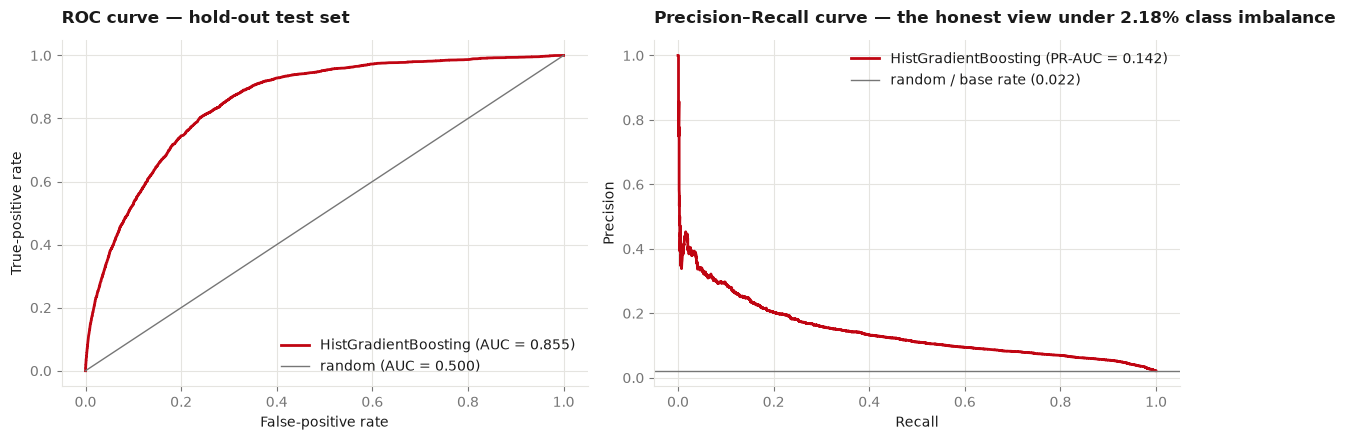

In [27]:
fpr, tpr, _ = roc_curve(y_test, proba_gbm)
prec, rec, _ = precision_recall_curve(y_test, proba_gbm)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
a1.plot(fpr, tpr, color=RED, linewidth=2, label=f'HistGradientBoosting (AUC = {auc_gbm:.3f})')
a1.plot([0, 1], [0, 1], color=MUTED, linewidth=1, label='random (AUC = 0.500)')
a1.set_title('ROC curve — hold-out test set')
a1.set_xlabel('False-positive rate'); a1.set_ylabel('True-positive rate'); a1.legend(loc='lower right')
a2.plot(rec, prec, color=RED, linewidth=2, label=f'HistGradientBoosting (PR-AUC = {ap_gbm:.3f})')
a2.axhline(y_test.mean(), color=MUTED, linewidth=1, label=f'random / base rate ({y_test.mean():.3f})')
a2.set_title('Precision–Recall curve — the honest view under 2.18% class imbalance')
a2.set_xlabel('Recall'); a2.set_ylabel('Precision'); a2.legend(loc='upper right')
plt.tight_layout(); plt.show()

### 3B.5 From probability to a business decision — the "review the top 10%" rule
The client cannot review every deal. So we rank all test deals by predicted risk and ask: **if the pricing team reviews
just the riskiest 10%, how many of the actual loss-making deals do they catch?**

In [28]:
order = np.argsort(-proba_gbm)
top10 = order[:int(0.10 * len(proba_gbm))]
capture  = y_test.iloc[top10].sum() / y_test.sum()
precision_in_flagged = y_test.iloc[top10].mean()
print(f'Reviewing the top 10% riskiest deals catches {capture:.1%} of ALL loss-making sales.')
print(f'Of the flagged deals, {precision_in_flagged:.1%} truly lose money '
      f'({precision_in_flagged/y_test.mean():.1f}x better than reviewing at random).')

Reviewing the top 10% riskiest deals catches 50.6% of ALL loss-making sales.
Of the flagged deals, 11.0% truly lose money (5.1x better than reviewing at random).


### 3B.6 What drives the risk? — permutation importance

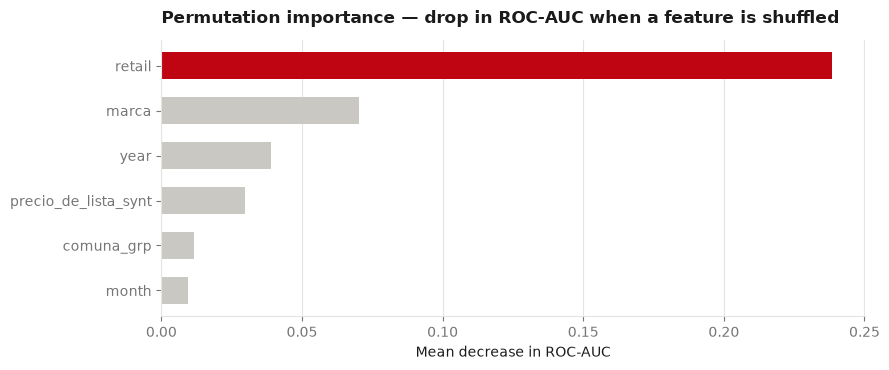

retail                  0.238342
marca                   0.070250
year                    0.039073
precio_de_lista_synt    0.029569
comuna_grp              0.011708
month                   0.009526
dtype: float64

In [29]:
from sklearn.inspection import permutation_importance
# small sample keeps permutation importance fast; seeded for reproducibility
Xs = X_test.sample(20000, random_state=SEED); ys = y_test.loc[Xs.index]
imp = permutation_importance(gbm, Xs, ys, scoring='roc_auc', n_repeats=5, random_state=SEED, n_jobs=-1)
imp_s = pd.Series(imp.importances_mean, index=num_features + cat_features).sort_values()

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.barh(imp_s.index, imp_s.values, height=.6,
        color=[RED if v >= imp_s.max() * .5 else '#c9c8c3' for v in imp_s.values])
ax.set_title('Permutation importance — drop in ROC-AUC when a feature is shuffled')
ax.set_xlabel('Mean decrease in ROC-AUC'); ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()
imp_s.sort_values(ascending=False)

**Model B insight:** loss risk is driven mainly by **brand, list price and channel** — consistent with the EDA
findings that specific brands (Mazda, Samsung) carry the highest loss rates and that DERCO's own stores close
below cost ~11× more often than the dealer network. The model turns that into a **deal-level watchlist** the
pricing team can act on daily.

---
# Stage 4 · Communicate — insights, recommendation, dashboard

### 4.1 The five insights, ranked by decision impact

1. **China won the shelf.** Chinese brands went **12% → 52%** of sales (2009→2022). They are no longer a hedge — they
   are the core business.
2. **DERCO is transactional, not relational.** **86%** of customers buy once; **Champions (14%) drive ~26% of margin.**
   A retention program aimed at Champions + one-timer→repeat conversion is the top growth lever.
3. **~6.8 bn CLP leaks through loss-making deals (2.18%)** — about **2.7% of all retail margin**. A model that flags
   the riskiest 10% of deals catches **~50%** of that leak for pricing review, and the leak is concentrated in the
   **own-store channel** (5.4% of deals vs 0.5% at dealers).
4. **Single-brand dependence.** Suzuki ≈ 39% of volume — resilient today, fragile if Suzuki stumbles.
5. **Geographic over-exposure.** Top-10 comunas ≈ 33% of sales — growth headroom sits in under-served comunas.

### 4.2 The recommendation (one decision)
> **Rebalance DERCO's commercial model around three moves for FY2026:**
> **(1) Fund a Champions-retention + one-timer-conversion program** (loyalty CRM) — the 14% that already repeat are the
> cheapest margin to grow.
> **(2) Formalise the Chinese-brand portfolio** as a first-class line (pricing, stock, marketing) — it is already the
> majority of sales.
> **(3) Deploy the loss-deal classifier** as a pre-approval check on the riskiest 10% of deals, starting with the
> own-store channel where the leak concentrates, to recover part of the ~6.8 bn CLP.

### 4.3 The stakeholder dashboard

Stage 4 is where analysis becomes a decision. Below we build the **one-screen KPI dashboard** the Commercial
Director actually looks at: the six numbers that carry the recommendation, plus the two charts behind them.
The same six KPIs drive the interactive deck in `presentation/index.html`, and the export cell after it writes
`presentation/metrics.json` so **every figure on a slide traces back to this notebook**.

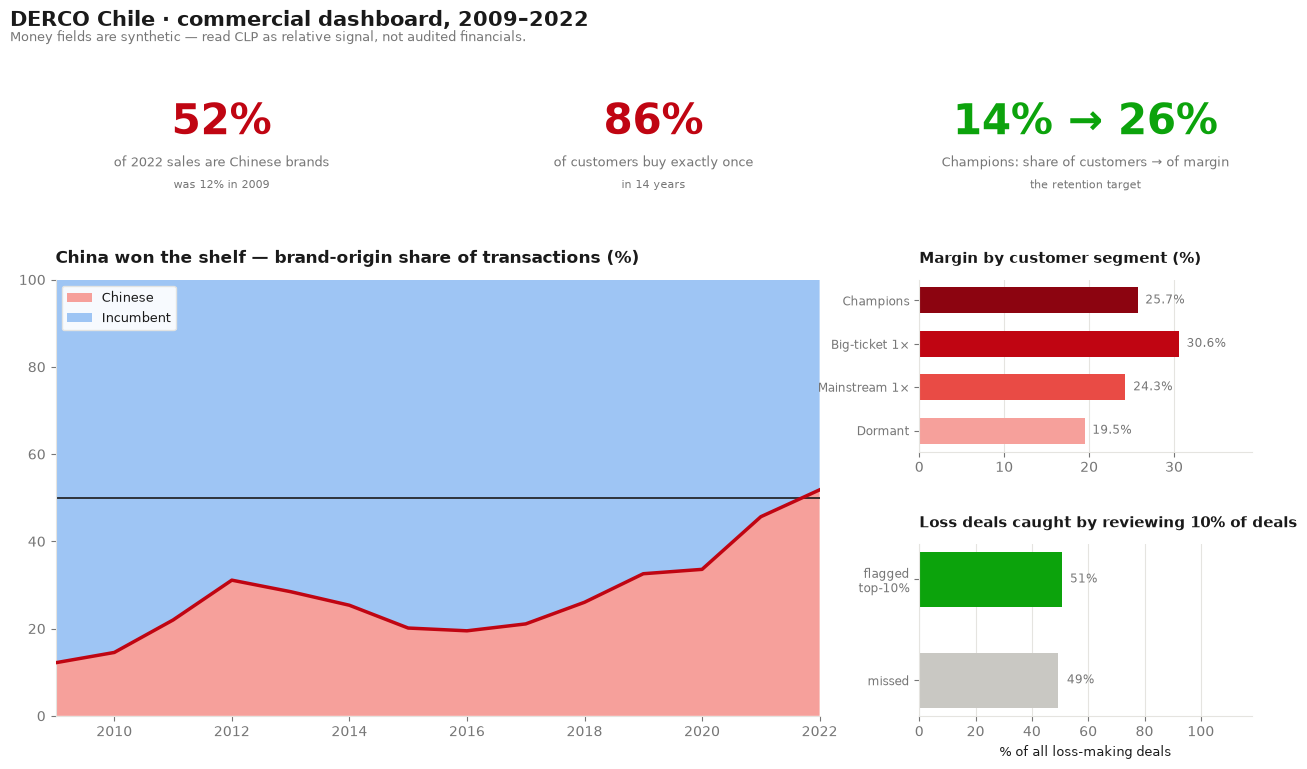

Saved presentation/dashboard.png — the static dashboard embedded in the slide deck.


In [30]:
def kpi(ax, value, label, color=INK, note=None):
    """One stat tile: the number IS the chart — no decoration around it."""
    ax.axis('off')
    ax.text(.5, .62, value, ha='center', va='center', fontsize=30, fontweight='bold', color=color)
    ax.text(.5, .24, label, ha='center', va='center', fontsize=9.5, color=MUTED)
    if note:
        ax.text(.5, .02, note, ha='center', va='center', fontsize=8, color=MUTED)

chinese_now  = origin_share.loc[2022, 'Chinese']
champ_cust   = (rfm.segment_name == 'Champions (repeat, high-value)').mean() * 100
champ_margin = rfm.loc[rfm.segment_name == 'Champions (repeat, high-value)', 'margin'].sum() / rfm.margin.sum() * 100
one_time     = (rfm.frequency == 1).mean() * 100

fig = plt.figure(figsize=(13, 7.8))
gs = fig.add_gridspec(3, 3, height_ratios=[.60, 1, 1], hspace=.62, wspace=.30,
                      left=.055, right=.975, top=.88, bottom=.07)

fig.suptitle('DERCO Chile · commercial dashboard, 2009–2022', x=.02, y=.975, ha='left',
             fontsize=15, fontweight='bold')
fig.text(.02, .935, 'Money fields are synthetic — read CLP as relative signal, not audited financials.',
         ha='left', fontsize=9, color=MUTED)

kpi(fig.add_subplot(gs[0, 0]), f'{chinese_now:.0f}%', 'of 2022 sales are Chinese brands', RED, 'was 12% in 2009')
kpi(fig.add_subplot(gs[0, 1]), f'{one_time:.0f}%', 'of customers buy exactly once', RED, 'in 14 years')
kpi(fig.add_subplot(gs[0, 2]), f'{champ_cust:.0f}% → {champ_margin:.0f}%',
    'Champions: share of customers → of margin', GREEN, 'the retention target')

# left panel: the structural shift (the headline)
ax1 = fig.add_subplot(gs[1:, 0:2])
ax1.stackplot(origin_share.index, origin_share['Chinese'], origin_share['Incumbent'],
              colors=[RED_FILL, BLUE_FILL], labels=['Chinese', 'Incumbent'])
ax1.plot(origin_share.index, origin_share['Chinese'], color=RED, linewidth=2.5, zorder=3)
ax1.axhline(50, color=INK, linewidth=1.2, zorder=2)
ax1.set_title('China won the shelf — brand-origin share of transactions (%)')
ax1.set_ylim(0, 100); ax1.set_xlim(origin_share.index.min(), origin_share.index.max())
ax1.grid(visible=False); ax1.legend(loc='upper left', fontsize=9, frameon=True, facecolor='white', framealpha=.92, edgecolor=GRID)

# right top: where the margin sits. Short labels are set WITH the ticks, so they cannot drift.
ax2 = fig.add_subplot(gs[1, 2])
ms = (rfm.groupby('segment_name').margin.sum() / rfm.margin.sum() * 100).reindex(SEG_ORDER)
short = [s.split(' (')[0].replace(' / lapsed', '').replace(' one-timers', ' 1×') for s in ms.index][::-1]
ypos = range(len(ms))
ax2.barh(list(ypos), ms.values[::-1], height=.6, color=[SEG_COLOR[s] for s in ms.index[::-1]])
ax2.set_yticks(list(ypos)); ax2.set_yticklabels(short, fontsize=8.5)
ax2.set_title('Margin by customer segment (%)', fontsize=10.5)
ax2.set_xlim(0, ms.max() * 1.28); ax2.grid(axis='y', visible=False)
for y, v in enumerate(ms.values[::-1]):
    ax2.text(v + ms.max() * .03, y, f'{v:.1f}%', va='center', fontsize=8.5, color=MUTED)

# right bottom: the leak the classifier plugs — flagged on top, the story first
ax3 = fig.add_subplot(gs[2, 2])
vals = [(1 - capture) * 100, capture * 100]          # bottom-to-top: missed, flagged
ax3.barh([0, 1], vals, height=.55, color=['#c9c8c3', GREEN])
ax3.set_yticks([0, 1]); ax3.set_yticklabels(['missed', 'flagged\ntop-10%'], fontsize=8.5)
ax3.set_title('Loss deals caught by reviewing 10% of deals', fontsize=10.5)
ax3.set_xlim(0, 118); ax3.set_xlabel('% of all loss-making deals', fontsize=9)
ax3.grid(axis='y', visible=False)
for y, v in enumerate(vals):
    ax3.text(v + 3, y, f'{v:.0f}%', va='center', fontsize=8.5, color=MUTED)

plt.savefig(PRES / 'dashboard.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved presentation/dashboard.png — the static dashboard embedded in the slide deck.')

In [31]:
import json
metrics = {
  'raw_rows': 550033,                       # rows in the source .xlsx, before the 1 unusable row is dropped
  'rows': int(len(df)),
  'customers': int(df.encrypt_rut.nunique()),
  'brands': int(df.marca.nunique()),
  'models': int(df.detalle.nunique()),
  'comunas': int(df.loc[df.comuna != 'UNKNOWN', 'comuna'].nunique()),   # excludes the UNKNOWN bucket
  'date_min': str(df.fecha_transaccion.min().date()),
  'date_max': str(df.fecha_transaccion.max().date()),
  'ces_share': round((df.retail=='ces').mean()*100,1),
  'ces_margin_pct': round(float(ch.loc['ces','margin_%']),2),
  'propio_margin_pct': round(float(ch.loc['propio','margin_%']),2),
  'suzuki_share': round((df.marca=='Suzuki').mean()*100,1),
  'peak_month': int(seasonal.idxmax()),
  'trough_month': int(seasonal.idxmin()),
  'chinese_2009': round(origin_share.loc[2009,'Chinese'],1),
  'chinese_2021': round(origin_share.loc[2021,'Chinese'],1),
  'chinese_2022': round(origin_share.loc[2022,'Chinese'],1),
  'chinese_share_by_year': {int(y): round(float(v),1) for y, v in origin_share['Chinese'].items()},
  'brand_share': {k: round(float(v),1) for k, v in (df.marca.value_counts()/len(df)*100).items()},
  'one_time_pct': round((rfm.frequency==1).mean()*100,1),
  'repeat_pct': round((rfm.frequency>=2).mean()*100,1),
  'segment_cust_pct': {s: round(float((rfm.segment_name==s).mean()*100),1) for s in SEG_ORDER},
  'segment_margin_pct': {s: round(float(rfm.loc[rfm.segment_name==s,'margin'].sum()/rfm.margin.sum()*100),1) for s in SEG_ORDER},
  'champions_cust_pct': round((rfm.segment_name=='Champions (repeat, high-value)').mean()*100,1),
  'champions_margin_pct': round(rfm[rfm.segment_name=='Champions (repeat, high-value)'].margin.sum()/rfm.margin.sum()*100,1),
  'loss_rate_pct': round(df.loss_making.mean()*100,2),
  'loss_n': int(df.loss_making.sum()),
  'loss_bn': round(df.loc[df.loss_making==1,'margen_retail'].sum()/1e9,2),
  'top10_comuna_share': round(cum.iloc[9],1),
  'gbm_auc': round(float(auc_gbm),3),
  'gbm_prauc': round(float(ap_gbm),3),
  'gbm_cv_auc': round(float(cv.mean()),3),
  'gbm_cv_std': round(float(cv.std()),3),
  'top10_capture': round(float(capture)*100,1),
  'top10_lift': round(float(precision_in_flagged/y_test.mean()),1),
}
PRES.mkdir(parents=True, exist_ok=True)
with open(PRES / 'metrics.json', 'w') as f: json.dump(metrics, f, indent=2)
print(json.dumps(metrics, indent=2))

{
  "raw_rows": 550033,
  "rows": 550032,
  "customers": 464226,
  "brands": 9,
  "models": 1543,
  "comunas": 511,
  "date_min": "2009-05-05",
  "date_max": "2022-03-28",
  "ces_share": 65.1,
  "ces_margin_pct": 6.24,
  "propio_margin_pct": 5.2,
  "suzuki_share": 38.8,
  "peak_month": 8,
  "trough_month": 4,
  "chinese_2009": 12.2,
  "chinese_2021": 45.6,
  "chinese_2022": 51.8,
  "chinese_share_by_year": {
    "2009": 12.2,
    "2010": 14.5,
    "2011": 22.0,
    "2012": 31.1,
    "2013": 28.5,
    "2014": 25.3,
    "2015": 20.1,
    "2016": 19.5,
    "2017": 21.1,
    "2018": 26.0,
    "2019": 32.6,
    "2020": 33.6,
    "2021": 45.6,
    "2022": 51.8
  },
  "brand_share": {
    "Suzuki": 38.8,
    "Mazda": 17.8,
    "Renault": 10.9,
    "JAC Cars": 9.1,
    "Great Wall": 8.5,
    "Changan": 8.2,
    "Samsung": 3.5,
    "Geely": 1.7,
    "Haval": 1.6
  },
  "one_time_pct": 85.9,
  "repeat_pct": 14.1,
  "segment_cust_pct": {
    "Champions (repeat, high-value)": 14.0,
    "Big-ticket

---
# Stage 5 · Ethics, privacy & bias

Every number above is a claim about real people who bought a real car. This stage states what we are allowed to
conclude, who could be harmed if we over-claim, and which of our own choices were made to limit that harm. It is
written as decisions the team took, not as a disclaimer.

### 5.1 Privacy — a hash is not anonymity

- **`encrypt_rut` is pseudonymous, not anonymous.** It is a one-way hash of the customer RUT. A RUT is short and
  check-digit-validated, so anyone holding the same hash function can enumerate candidate RUTs and match them back.
  We therefore treat the column as **personal data** (Chilean Ley 19.628 logic), not as a free-of-charge anonymised key.
- **What we did with it:** it is used only as a *grouping key* to build the RFM table (how many purchases, how recent,
  how much). It is never a model feature, never printed at row level in this notebook, and never leaves the repo in
  any deliverable — the deck, the PDF and the dashboard show aggregates only.
- **Data minimisation.** `direccion` (street address) is present in the source file and is **dropped in Stage 2**: it
  is not in `derco_sales_clean.parquet`, not in the sample CSV, and not in any model. `comuna` is kept because
  municipality-level geography is what the business decision needs, and it is coarse enough not to locate a household.
- **If this went to production**, the retention program would need a lawful basis for contacting customers and a
  documented retention period. Nothing in this analysis creates that basis.

### 5.2 Bias — who this analysis systematically sees, and who it misses

- **Geographic skew.** The top-10 comunas hold **33.4%** of all rows and are concentrated in the Santiago metro. Our
  "valuable customer" is therefore partly a proxy for "urban customer". A retention budget allocated straight off the
  segment table would quietly under-serve rural comunas — a redlining risk. Any rollout should check spend per comuna
  against population, not only against historical margin.
- **Survivorship.** The dataset contains closed DERCO sales only. Customers who walked away, bought from a competitor,
  or were refused finance are invisible. "86% buy once" is therefore a statement about *DERCO's* record, and cannot be
  read as a statement about customer loyalty in the Chilean market.
- **Feedback loop in Model B.** The classifier learns that `propio` deals fail more often, so it flags `propio` deals
  more often, so reviewers see more `propio` cases and confirm the pattern. Mitigation: monitor the **flag rate by
  channel and comuna** after deployment, and re-fit on post-deployment data rather than on the historical file alone.
- **Segments are a convenience, not a truth.** Silhouette at k = 4 is 0.39. The four groups are a usable marketing
  partition; they are not four naturally separated populations, and no customer should be told which one they are in.
- **Human in the loop.** Both models advise; people decide. Model B produces a review queue for the pricing team, never
  an automatic rejection — see §3B.5 for the exact decision rule and §5.3 for why the precision level demands it.

### 5.3 Honest limitations
- **Synthetic money.** `precio_de_lista_synt` and `margen_retail` are obfuscated. **All CLP amounts (incl. the "6.8 bn
  leak" and margin shares) are relative signals, not audited financials.** The *direction* is trustworthy; the *level* is not.
- **Class imbalance.** Loss-making deals are 2.18% of data; PR-AUC (0.14) is modest in absolute terms — though it is
  ~6.5× the 0.022 base rate a random ranker would achieve. The model is a **triage aid**, not an automatic reject: a
  human reviews every flag.
- **Cluster quality is moderate.** The k = 4 silhouette (0.39) says the segments are usable, not that they are
  cleanly separated spheres; they are a marketing convenience, not a law of nature.
- **Low repeat rate + 14-year window.** We cannot tell "genuinely one-time buyer" from "key not stable across years"
  without business confirmation. The loyalty conclusion needs that validation before budget is committed.
- **No causality.** Everything here is correlational. "Chinese brands rose" does not by itself say *why*; a pricing or
  supply experiment would be needed to attribute cause.
- **Partial end-years.** 2009 (from May) and 2022 (to March) are partial — never compare their *totals* to full years.

---
# 6 · AI-use disclosure (course policy §7)

- **Tools used:** an AI coding assistant (Claude) was used as a *pair-programmer* — to scaffold boilerplate (plot
  styling, pipeline wiring), suggest the RFM/KMeans and leakage-safe classifier structure, and draft explanatory prose.
- **What the team owns:** the business framing, the choice of question and KPIs, the k=4 decision, the leakage rule, the
  interpretation of every result, and the final recommendation. Every line was reviewed and can be defended by the team
  in Q&A, as required.
- **Not used for:** inventing data or numbers — every figure in this notebook is computed from the provided dataset by
  the code above and reproduces on *Restart & Run All*.

---
### Contribution summary
| Member | Owned |
|---|---|
| **Vicente Rodríguez** | Stage 1 framing & KPIs, repo/reproducibility, README |
| **Agustín Reyes** | Stage 2 data prep, EDA, data-quality audit |
| **Luis-Felipe Cáceres** | Stage 3 modeling (segmentation + classifier), validation |
| **Baptiste Vial** | Stage 4 insights & dashboard, Stage 5 ethics, presentation |

*All four contributed to the analysis and all four present.*